# NB_07 — Ablación económica usando scores de modelos supervisados


**Objetivo del notebook:** evaluar si los scores generados en el NB_06B permiten seleccionar subconjuntos de señales con mejor comportamiento económico que el baseline técnico puro.

## Idea central

En el NB_06B se observó que los modelos supervisados, especialmente **Random Forest**, no funcionaban como clasificadores binarios fuertes, pero sí mostraban utilidad como mecanismo de **ranking**. Este notebook prueba si esa priorización se traduce en una mejora económica a nivel de señales.

La pregunta que responde este notebook es:

> Si tomo las señales mejor puntuadas por el modelo, ¿mejora la tasa de éxito, el retorno medio y el perfil de riesgo respecto de ejecutar todas las señales técnicas del período de test?

Este notebook trabaja a nivel de **señal** y usa los resultados `outcome_ret_combo` ya calculados previamente. Por tanto, es una **ablación económica signal-level**, no todavía una simulación completa de cartera con capital limitado, solapamiento de posiciones y sizing dinámico. Esa simulación más estricta puede hacerse después como NB_07B.

In [1]:
# ============================================================
# 1. Imports y configuración general
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

# Estructura esperada:
# JUNIO/
# ├── NB_05/outputs_nb05/dataset_supervisado_tecnico_v1.csv.zip
# ├── NB_06/outputs_nb06b/predictions_walkforward_nb06b.csv.zip
# └── NB_07/NB_07_ablation_backtest_ml_scores_PARA_EJECUTAR.ipynb

BASE_DIR = Path.cwd()
NB05_OUTPUTS = BASE_DIR.parent / 'NB_05' / 'outputs_nb05'
NB06B_OUTPUTS = BASE_DIR.parent / 'NB_06' / 'outputs_nb06b'

OUT_DIR = BASE_DIR / 'outputs_nb07'
FIG_DIR = OUT_DIR / 'figures'
TABLE_DIR = OUT_DIR / 'tables'
EQUITY_DIR = FIG_DIR / 'equity_proxy'
YEAR_DIR = FIG_DIR / 'yearly'

for d in [OUT_DIR, FIG_DIR, TABLE_DIR, EQUITY_DIR, YEAR_DIR]:
    d.mkdir(parents=True, exist_ok=True)

PRED_PATH = NB06B_OUTPUTS / 'predictions_walkforward_nb06b.csv.zip'
DATASET_PATH = NB05_OUTPUTS / 'dataset_supervisado_tecnico_v1.csv.zip'

print('BASE_DIR:', BASE_DIR)
print('NB05_OUTPUTS:', NB05_OUTPUTS)
print('NB06B_OUTPUTS:', NB06B_OUTPUTS)
print('OUT_DIR:', OUT_DIR)

if not PRED_PATH.exists():
    raise FileNotFoundError(f'No se encontró el archivo de predicciones: {PRED_PATH}')
if not DATASET_PATH.exists():
    print('Aviso: no se encontró el dataset del NB_05. Este notebook puede continuar con las predicciones del NB_06B.')

BASE_DIR: /Users/rbr/TFM_MVP/JUNIO/NB_07
NB05_OUTPUTS: /Users/rbr/TFM_MVP/JUNIO/NB_05/outputs_nb05
NB06B_OUTPUTS: /Users/rbr/TFM_MVP/JUNIO/NB_06/outputs_nb06b
OUT_DIR: /Users/rbr/TFM_MVP/JUNIO/NB_07/outputs_nb07


In [2]:
# ============================================================
# 2. Carga de predicciones walk-forward del NB_06B
# ============================================================

pred = pd.read_csv(PRED_PATH, parse_dates=['signal_date', 'entry_date'])

required_cols = [
    'signal_id', 'ticker', 'signal_date', 'entry_date', 'signal_year',
    'target_combo_positive', 'outcome_ret_combo', 'fold', 'model', 'score',
    'pred_fixed_0_50', 'threshold_optimized_f1', 'pred_optimized_f1'
]
missing = [c for c in required_cols if c not in pred.columns]
if missing:
    raise ValueError(f'Faltan columnas esperadas en predictions_walkforward_nb06b: {missing}')

pred['test_year'] = pred['entry_date'].dt.year
pred['outcome_ret_combo'] = pred['outcome_ret_combo'].astype(float)
pred['target_combo_positive'] = pred['target_combo_positive'].astype(int)

print('Filas predicciones:', len(pred))
print('Modelos:', pred['model'].unique())
print('Folds:', sorted(pred['fold'].unique()))
print('Años test:', sorted(pred['test_year'].unique()))
display(pred.head())

Filas predicciones: 13040
Modelos: ['Dummy' 'LogisticRegression' 'RandomForest' 'XGBoost']
Folds: [1, 2, 3]
Años test: [2023, 2024, 2025]


,signal_id,ticker,signal_date,entry_date,signal_year,target_combo_positive,outcome_ret_combo,fold,model,score,pred_fixed_0_50,threshold_optimized_f1,pred_optimized_f1,test_year
0,4896,AMT,2023-01-03,2023-01-03,2023,1,0.0230,1,Dummy,1.0000,1,0.5000,1,2023
1,4897,A,2023-01-04,2023-01-04,2023,0,-0.0018,1,Dummy,1.0000,1,0.5000,1,2023
2,4898,ABT,2023-01-04,2023-01-04,2023,0,-0.0310,1,Dummy,1.0000,1,0.5000,1,2023
3,4899,ADI,2023-01-04,2023-01-04,2023,1,0.1004,1,Dummy,1.0000,1,0.5000,1,2023
4,4900,BDX,2023-01-04,2023-01-04,2023,0,-0.0720,1,Dummy,1.0000,1,0.5000,1,2023


In [3]:
# ============================================================
# 3. Baseline técnico de test: señales V4 sin filtro ML
# ============================================================

# Las predicciones tienen una fila por modelo. Para el baseline se elimina duplicación por señal/fold.
baseline = pred.drop_duplicates(subset=['fold', 'signal_id']).copy()
baseline['strategy'] = 'BASELINE_TECNICO_ALL'
baseline['strategy_type'] = 'baseline'
baseline['selection_detail'] = 'Todas las señales V4 del período de test'
baseline['selected_by_model'] = 'N/A'

print('Señales únicas en test:', len(baseline))
print('Años test baseline:', sorted(baseline['test_year'].unique()))
print('Success rate baseline:', baseline['target_combo_positive'].mean())
print('Retorno medio baseline:', baseline['outcome_ret_combo'].mean())
display(baseline[['signal_id', 'ticker', 'entry_date', 'test_year', 'target_combo_positive', 'outcome_ret_combo']].head())

Señales únicas en test: 3260
Años test baseline: [2023, 2024, 2025]
Success rate baseline: 0.5193251533742331
Retorno medio baseline: 0.02283530586848847


,signal_id,ticker,entry_date,test_year,target_combo_positive,outcome_ret_combo
0,4896,AMT,2023-01-03,2023,1,0.0230
1,4897,A,2023-01-04,2023,0,-0.0018
2,4898,ABT,2023-01-04,2023,0,-0.0310
3,4899,ADI,2023-01-04,2023,1,0.1004
4,4900,BDX,2023-01-04,2023,0,-0.0720


In [4]:
# ============================================================
# 4. Funciones auxiliares de selección y métricas
# ============================================================

def max_drawdown_from_returns(returns: pd.Series) -> float:
    """Calcula max drawdown a partir de una serie de retornos periódicos."""
    if returns.empty:
        return np.nan
    equity = (1 + returns.fillna(0)).cumprod()
    peak = equity.cummax()
    dd = equity / peak - 1
    return float(dd.min())


def daily_proxy_returns(df: pd.DataFrame) -> pd.DataFrame:
    """Crea retornos diarios proxy promediando señales seleccionadas por fecha de entrada."""
    if df.empty:
        return pd.DataFrame(columns=['entry_date', 'daily_mean_return', 'n_signals'])
    out = (
        df.groupby('entry_date')
          .agg(daily_mean_return=('outcome_ret_combo', 'mean'), n_signals=('signal_id', 'nunique'))
          .reset_index()
          .sort_values('entry_date')
    )
    out['equity_proxy'] = (1 + out['daily_mean_return']).cumprod()
    out['drawdown_proxy'] = out['equity_proxy'] / out['equity_proxy'].cummax() - 1
    return out


def calc_strategy_metrics(df: pd.DataFrame, strategy: str, strategy_type: str, selected_by_model: str, selection_detail: str) -> dict:
    """Calcula métricas signal-level y proxy diaria para un subconjunto de señales."""
    if df.empty:
        return {
            'strategy': strategy, 'strategy_type': strategy_type, 'selected_by_model': selected_by_model,
            'selection_detail': selection_detail, 'n_signals': 0, 'n_entry_days': 0,
            'success_rate': np.nan, 'mean_return': np.nan, 'median_return': np.nan,
            'sum_return_signal_level': np.nan, 'equal_signal_compounded_return': np.nan,
            'daily_proxy_compounded_return': np.nan, 'daily_proxy_max_drawdown': np.nan,
            'daily_proxy_mean_return': np.nan, 'daily_proxy_volatility': np.nan,
            'daily_proxy_sharpe_like': np.nan,
            'best_signal_return': np.nan, 'worst_signal_return': np.nan,
        }

    d = df.copy()
    dpr = daily_proxy_returns(d)
    daily_ret = dpr['daily_mean_return'] if not dpr.empty else pd.Series(dtype=float)
    daily_vol = daily_ret.std(ddof=1) if len(daily_ret) > 1 else np.nan
    daily_mean = daily_ret.mean() if len(daily_ret) > 0 else np.nan
    sharpe_like = (daily_mean / daily_vol * np.sqrt(252)) if (pd.notna(daily_vol) and daily_vol != 0) else np.nan

    return {
        'strategy': strategy,
        'strategy_type': strategy_type,
        'selected_by_model': selected_by_model,
        'selection_detail': selection_detail,
        'n_signals': int(d['signal_id'].nunique()),
        'n_entry_days': int(d['entry_date'].nunique()),
        'success_rate': float(d['target_combo_positive'].mean()),
        'mean_return': float(d['outcome_ret_combo'].mean()),
        'median_return': float(d['outcome_ret_combo'].median()),
        'sum_return_signal_level': float(d['outcome_ret_combo'].sum()),
        'equal_signal_compounded_return': float((1 + d['outcome_ret_combo']).prod() - 1),
        'daily_proxy_compounded_return': float((1 + daily_ret).prod() - 1) if len(daily_ret) > 0 else np.nan,
        'daily_proxy_max_drawdown': max_drawdown_from_returns(daily_ret),
        'daily_proxy_mean_return': float(daily_mean) if pd.notna(daily_mean) else np.nan,
        'daily_proxy_volatility': float(daily_vol) if pd.notna(daily_vol) else np.nan,
        'daily_proxy_sharpe_like': float(sharpe_like) if pd.notna(sharpe_like) else np.nan,
        'best_signal_return': float(d['outcome_ret_combo'].max()),
        'worst_signal_return': float(d['outcome_ret_combo'].min()),
    }


def select_top_fraction(df_model: pd.DataFrame, top_fraction: float) -> pd.DataFrame:
    """Selecciona el top X% por score dentro de cada fold para evitar mezclar años."""
    parts = []
    for fold, sub in df_model.groupby('fold'):
        sub = sub.sort_values('score', ascending=False).copy()
        n = max(1, int(np.ceil(len(sub) * top_fraction)))
        parts.append(sub.head(n))
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame(columns=df_model.columns)

In [5]:
# ============================================================
# 5. Construcción de estrategias de ablación
# ============================================================

strategy_frames = []
metrics_rows = []

# 5.1 Baseline técnico: todas las señales de test
strategy_frames.append(baseline.copy())
metrics_rows.append(calc_strategy_metrics(
    baseline,
    strategy='BASELINE_TECNICO_ALL',
    strategy_type='baseline',
    selected_by_model='N/A',
    selection_detail='Todas las señales V4 de los años de test'
))

models = list(pred['model'].unique())
top_fractions = [0.10, 0.20, 0.30]

for model_name in models:
    dfm = pred[pred['model'] == model_name].copy()

    # 5.2 Threshold fijo 0.50
    selected = dfm[dfm['pred_fixed_0_50'] == 1].copy()
    selected['strategy'] = f'{model_name}_THRESHOLD_0_50'
    selected['strategy_type'] = 'threshold_fixed_0_50'
    selected['selection_detail'] = 'Señales con score >= 0,50'
    selected['selected_by_model'] = model_name
    strategy_frames.append(selected)
    metrics_rows.append(calc_strategy_metrics(
        selected,
        strategy=f'{model_name}_THRESHOLD_0_50',
        strategy_type='threshold_fixed_0_50',
        selected_by_model=model_name,
        selection_detail='Señales con score >= 0,50'
    ))

    # 5.3 Threshold optimizado por F1 en validación
    selected = dfm[dfm['pred_optimized_f1'] == 1].copy()
    selected['strategy'] = f'{model_name}_THRESHOLD_OPT_F1'
    selected['strategy_type'] = 'threshold_optimized_f1'
    selected['selection_detail'] = 'Señales aprobadas con threshold optimizado por F1 en validación'
    selected['selected_by_model'] = model_name
    strategy_frames.append(selected)
    metrics_rows.append(calc_strategy_metrics(
        selected,
        strategy=f'{model_name}_THRESHOLD_OPT_F1',
        strategy_type='threshold_optimized_f1',
        selected_by_model=model_name,
        selection_detail='Threshold optimizado por F1 en validación'
    ))

    # 5.4 Top fractions por score
    for frac in top_fractions:
        selected = select_top_fraction(dfm, frac).copy()
        pct = int(frac * 100)
        selected['strategy'] = f'{model_name}_TOP_{pct}'
        selected['strategy_type'] = 'ranking_top_fraction'
        selected['selection_detail'] = f'Top {pct}% de señales por score dentro de cada fold'
        selected['selected_by_model'] = model_name
        strategy_frames.append(selected)
        metrics_rows.append(calc_strategy_metrics(
            selected,
            strategy=f'{model_name}_TOP_{pct}',
            strategy_type='ranking_top_fraction',
            selected_by_model=model_name,
            selection_detail=f'Top {pct}% de señales por score dentro de cada fold'
        ))

selected_signals_all = pd.concat(strategy_frames, ignore_index=True)
strategy_metrics = pd.DataFrame(metrics_rows)

# Métricas relativas vs baseline
baseline_success = strategy_metrics.loc[strategy_metrics['strategy'] == 'BASELINE_TECNICO_ALL', 'success_rate'].iloc[0]
baseline_mean_ret = strategy_metrics.loc[strategy_metrics['strategy'] == 'BASELINE_TECNICO_ALL', 'mean_return'].iloc[0]
baseline_daily_proxy = strategy_metrics.loc[strategy_metrics['strategy'] == 'BASELINE_TECNICO_ALL', 'daily_proxy_compounded_return'].iloc[0]

strategy_metrics['success_lift_vs_baseline'] = strategy_metrics['success_rate'] / baseline_success
strategy_metrics['mean_return_delta_vs_baseline'] = strategy_metrics['mean_return'] - baseline_mean_ret
strategy_metrics['daily_proxy_return_delta_vs_baseline'] = strategy_metrics['daily_proxy_compounded_return'] - baseline_daily_proxy

strategy_metrics = strategy_metrics.sort_values(['strategy_type', 'selected_by_model', 'strategy']).reset_index(drop=True)

display(strategy_metrics)

,strategy,strategy_type,selected_by_model,selection_detail,n_signals,n_entry_days,success_rate,mean_return,median_return,sum_return_signal_level,equal_signal_compounded_return,daily_proxy_compounded_return,daily_proxy_max_drawdown,daily_proxy_mean_return,daily_proxy_volatility,daily_proxy_sharpe_like,best_signal_return,worst_signal_return,success_lift_vs_baseline,mean_return_delta_vs_baseline,daily_proxy_return_delta_vs_baseline
0,BASELINE_TECNICO_ALL,baseline,N/A,Todas las señales V4 de los años de test,3260,592,0.5193,0.0228,0.0044,74.4431,"240,885,377,401,117,548,216,320.0000","114,416.0318",-0.9188,0.0231,0.0831,4.4109,1.3047,-0.3108,1.0000,0.0000,0.0000
1,Dummy_TOP_10,ranking_top_fraction,Dummy,Top 10% de señales por score dentro de cada fold,327,55,0.4801,0.0140,-0.0033,4.5722,16.9886,1.0495,-0.4546,0.0152,0.0671,3.5943,0.5398,-0.2063,0.9245,-0.0089,"-114,414.9823"
2,Dummy_TOP_20,ranking_top_fraction,Dummy,Top 20% de señales por score dentro de cada fold,653,118,0.4732,0.0118,-0.0045,7.6841,50.9566,4.7603,-0.6726,0.0182,0.0847,3.4107,0.8590,-0.2498,0.9112,-0.0111,"-114,411.2715"
3,Dummy_TOP_30,ranking_top_fraction,Dummy,Top 30% de señales por score dentro de cada fold,980,170,0.4806,0.0144,-0.0035,14.1030,"4,540.3188",15.7154,-0.7490,0.0194,0.0753,4.0782,0.9942,-0.2498,0.9255,-0.0084,"-114,400.3164"
4,LogisticRegression_TOP_10,ranking_top_fraction,LogisticRegression,Top 10% de señales por score dentro de cada fold,327,174,0.5596,0.0485,0.0177,15.8441,"151,730.2898","1,737.4513",-0.6590,0.0544,0.1572,5.4915,0.9942,-0.3079,1.0776,0.0256,"-112,678.5804"
5,LogisticRegression_TOP_20,ranking_top_fraction,LogisticRegression,Top 20% de señales por score dentro de cada fold,653,263,0.5360,0.0388,0.0096,25.3266,"163,995,835.5480","32,240.7919",-0.6848,0.0482,0.1363,5.6104,1.3047,-0.3079,1.0321,0.0159,"-82,175.2399"
6,LogisticRegression_TOP_30,ranking_top_fraction,LogisticRegression,Top 30% de señales por score dentro de cada fold,980,329,0.5582,0.0344,0.0123,33.7462,"163,362,212,726.5788","34,161.6179",-0.7045,0.0376,0.1112,5.3702,1.3047,-0.3079,1.0748,0.0116,"-80,254.4138"
7,RandomForest_TOP_10,ranking_top_fraction,RandomForest,Top 10% de señales por score dentro de cada fold,327,110,0.6575,0.0667,0.0402,21.8024,"42,435,847.7042",876.6278,-0.6507,0.0752,0.1621,7.3639,0.9942,-0.3079,1.2661,0.0438,"-113,539.4040"
8,RandomForest_TOP_20,ranking_top_fraction,RandomForest,Top 20% de señales por score dentro de cada fold,653,214,0.6003,0.0536,0.0285,34.9700,"866,063,478,243.8625","6,650.8964",-0.6586,0.0513,0.1529,5.3276,1.3047,-0.3079,1.1559,0.0307,"-107,765.1354"
9,RandomForest_TOP_30,ranking_top_fraction,RandomForest,Top 30% de señales por score dentro de cada fold,980,296,0.5949,0.0491,0.0263,48.1082,"21,739,151,447,649,416.0000","652,901.3987",-0.7506,0.0546,0.1406,6.1592,1.3047,-0.3079,1.1455,0.0263,"538,485.3669"


In [6]:
# ============================================================
# 6. Métricas por año de test
# ============================================================

def calc_yearly_metrics(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (strategy, strategy_type, model, year), sub in df.groupby(['strategy', 'strategy_type', 'selected_by_model', 'test_year']):
        rows.append({
            'strategy': strategy,
            'strategy_type': strategy_type,
            'selected_by_model': model,
            'test_year': int(year),
            'n_signals': int(sub['signal_id'].nunique()),
            'success_rate': float(sub['target_combo_positive'].mean()) if len(sub) else np.nan,
            'mean_return': float(sub['outcome_ret_combo'].mean()) if len(sub) else np.nan,
            'median_return': float(sub['outcome_ret_combo'].median()) if len(sub) else np.nan,
            'sum_return_signal_level': float(sub['outcome_ret_combo'].sum()) if len(sub) else np.nan,
        })
    return pd.DataFrame(rows).sort_values(['strategy', 'test_year'])

yearly_metrics = calc_yearly_metrics(selected_signals_all)
display(yearly_metrics.head(30))

,strategy,strategy_type,selected_by_model,test_year,n_signals,success_rate,mean_return,median_return,sum_return_signal_level
0,BASELINE_TECNICO_ALL,baseline,N/A,2023,907,0.4509,0.0084,-0.0129,7.5919
1,BASELINE_TECNICO_ALL,baseline,N/A,2024,1429,0.5808,0.0294,0.0166,42.0530
2,BASELINE_TECNICO_ALL,baseline,N/A,2025,924,0.4913,0.0268,-0.0024,24.7983
3,Dummy_THRESHOLD_0_50,threshold_fixed_0_50,Dummy,2023,907,0.4509,0.0084,-0.0129,7.5919
4,Dummy_THRESHOLD_OPT_F1,threshold_optimized_f1,Dummy,2023,907,0.4509,0.0084,-0.0129,7.5919
5,Dummy_TOP_10,ranking_top_fraction,Dummy,2023,91,0.2747,-0.0315,-0.0472,-2.8676
6,Dummy_TOP_10,ranking_top_fraction,Dummy,2024,143,0.5594,0.0164,0.0138,2.3403
7,Dummy_TOP_10,ranking_top_fraction,Dummy,2025,93,0.5591,0.0548,0.0091,5.0995
8,Dummy_TOP_20,ranking_top_fraction,Dummy,2023,182,0.2692,-0.0299,-0.0390,-5.4463
9,Dummy_TOP_20,ranking_top_fraction,Dummy,2024,286,0.5699,0.0147,0.0144,4.2001


In [7]:
# ============================================================
# 7. Exportación de tablas base
# ============================================================

strategy_metrics.to_csv(TABLE_DIR / 'strategy_metrics_nb07.csv', index=False)
yearly_metrics.to_csv(TABLE_DIR / 'yearly_strategy_metrics_nb07.csv', index=False)
selected_signals_all.to_csv(OUT_DIR / 'selected_signals_all_strategies_nb07.csv.zip', index=False, compression='zip')

print('Exportado:')
print(TABLE_DIR / 'strategy_metrics_nb07.csv')
print(TABLE_DIR / 'yearly_strategy_metrics_nb07.csv')
print(OUT_DIR / 'selected_signals_all_strategies_nb07.csv.zip')

Exportado:
/Users/rbr/TFM_MVP/JUNIO/NB_07/outputs_nb07/tables/strategy_metrics_nb07.csv
/Users/rbr/TFM_MVP/JUNIO/NB_07/outputs_nb07/tables/yearly_strategy_metrics_nb07.csv
/Users/rbr/TFM_MVP/JUNIO/NB_07/outputs_nb07/selected_signals_all_strategies_nb07.csv.zip


In [8]:
# ============================================================
# 8. Comparación principal de estrategias relevantes
# ============================================================

key_strategies = [
    'BASELINE_TECNICO_ALL',
    'LogisticRegression_TOP_10',
    'RandomForest_TOP_10',
    'RandomForest_TOP_20',
    'RandomForest_TOP_30',
    'XGBoost_TOP_10',
    'XGBoost_TOP_20',
    'XGBoost_TOP_30',
    'RandomForest_THRESHOLD_0_50',
    'XGBoost_THRESHOLD_0_50',
]

main_comp = strategy_metrics[strategy_metrics['strategy'].isin(key_strategies)].copy()
main_comp = main_comp.sort_values('mean_return', ascending=False)

display(main_comp[[
    'strategy', 'n_signals', 'success_rate', 'mean_return', 'median_return',
    'daily_proxy_compounded_return', 'daily_proxy_max_drawdown',
    'success_lift_vs_baseline', 'mean_return_delta_vs_baseline'
]])

main_comp.to_csv(TABLE_DIR / 'main_strategy_comparison_nb07.csv', index=False)

,strategy,n_signals,success_rate,mean_return,median_return,daily_proxy_compounded_return,daily_proxy_max_drawdown,success_lift_vs_baseline,mean_return_delta_vs_baseline
7,RandomForest_TOP_10,327,0.6575,0.0667,0.0402,876.6278,-0.6507,1.2661,0.0438
8,RandomForest_TOP_20,653,0.6003,0.0536,0.0285,"6,650.8964",-0.6586,1.1559,0.0307
10,XGBoost_TOP_10,327,0.6086,0.0500,0.0254,99.5178,-0.5894,1.1718,0.0272
9,RandomForest_TOP_30,980,0.5949,0.0491,0.0263,"652,901.3987",-0.7506,1.1455,0.0263
4,LogisticRegression_TOP_10,327,0.5596,0.0485,0.0177,"1,737.4513",-0.6590,1.0776,0.0256
11,XGBoost_TOP_20,653,0.5482,0.0356,0.0136,671.0658,-0.6543,1.0557,0.0127
12,XGBoost_TOP_30,980,0.5561,0.0321,0.0142,"1,157.8210",-0.7053,1.0709,0.0092
15,RandomForest_THRESHOLD_0_50,2350,0.5468,0.0305,0.0103,"1,316,598.8775",-0.8996,1.0529,0.0077
16,XGBoost_THRESHOLD_0_50,1836,0.5430,0.0281,0.0094,"74,459.5740",-0.8375,1.0456,0.0053
0,BASELINE_TECNICO_ALL,3260,0.5193,0.0228,0.0044,"114,416.0318",-0.9188,1.0000,0.0000


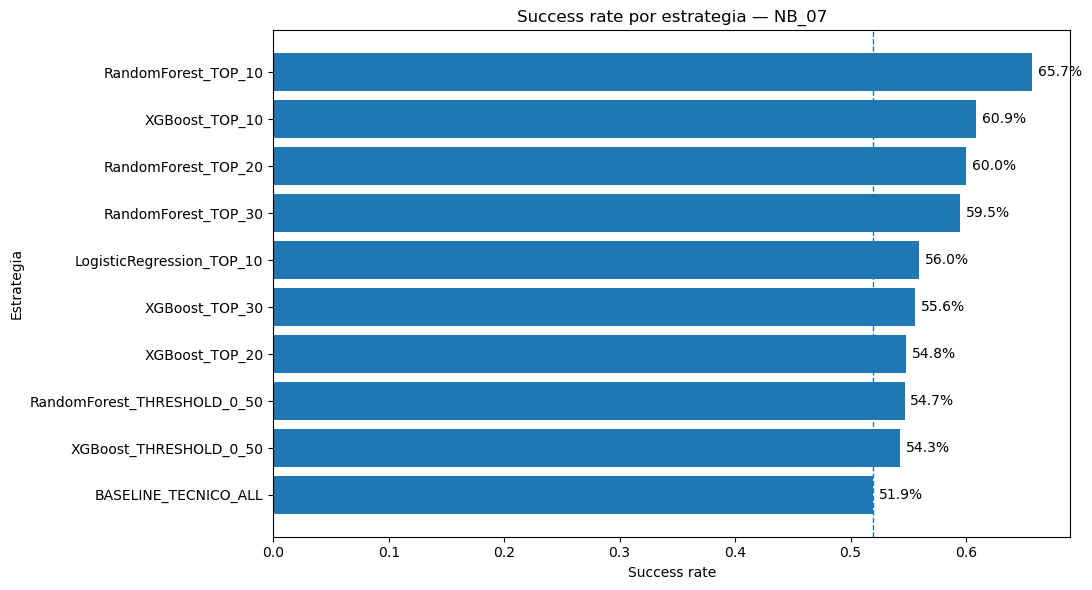

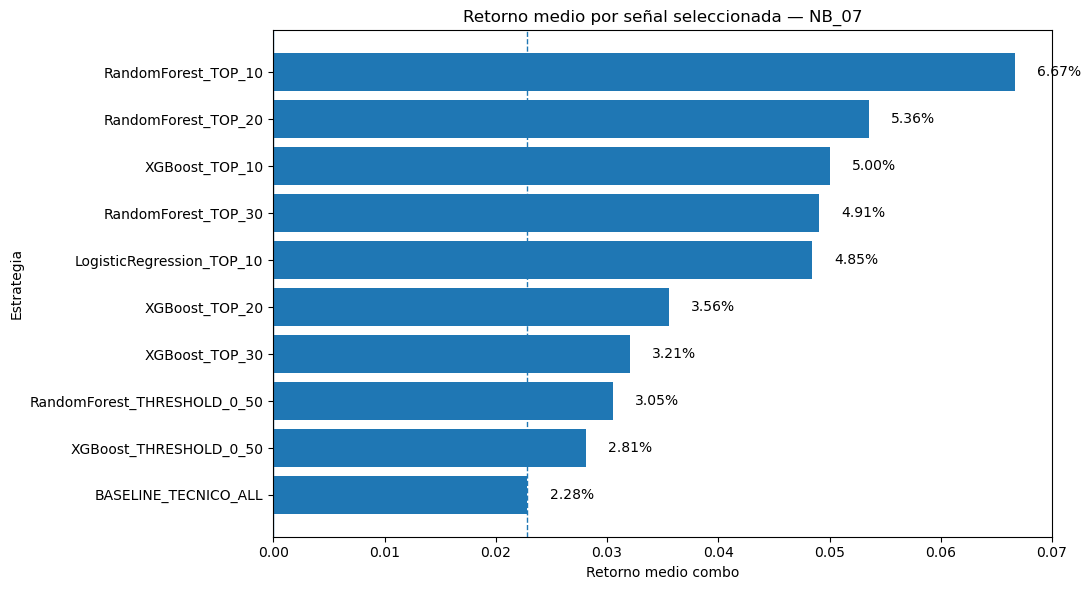

In [9]:
# ============================================================
# 9. Gráficos comparativos: success rate y retorno medio
# ============================================================

plot_df = main_comp.sort_values('success_rate', ascending=True)

plt.figure(figsize=(11, 6))
plt.barh(plot_df['strategy'], plot_df['success_rate'])
plt.axvline(baseline_success, linewidth=1, linestyle='--')
plt.title('Success rate por estrategia — NB_07')
plt.xlabel('Success rate')
plt.ylabel('Estrategia')
for i, v in enumerate(plot_df['success_rate']):
    plt.text(v + 0.005, i, f'{v:.1%}', va='center')
plt.tight_layout()
plt.savefig(FIG_DIR / 'strategy_success_rate_nb07.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close()

plot_df = main_comp.sort_values('mean_return', ascending=True)
plt.figure(figsize=(11, 6))
plt.barh(plot_df['strategy'], plot_df['mean_return'])
plt.axvline(baseline_mean_ret, linewidth=1, linestyle='--')
plt.axvline(0, linewidth=1)
plt.title('Retorno medio por señal seleccionada — NB_07')
plt.xlabel('Retorno medio combo')
plt.ylabel('Estrategia')
for i, v in enumerate(plot_df['mean_return']):
    plt.text(v + 0.002, i, f'{v:.2%}', va='center')
plt.tight_layout()
plt.savefig(FIG_DIR / 'strategy_mean_return_nb07.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close()

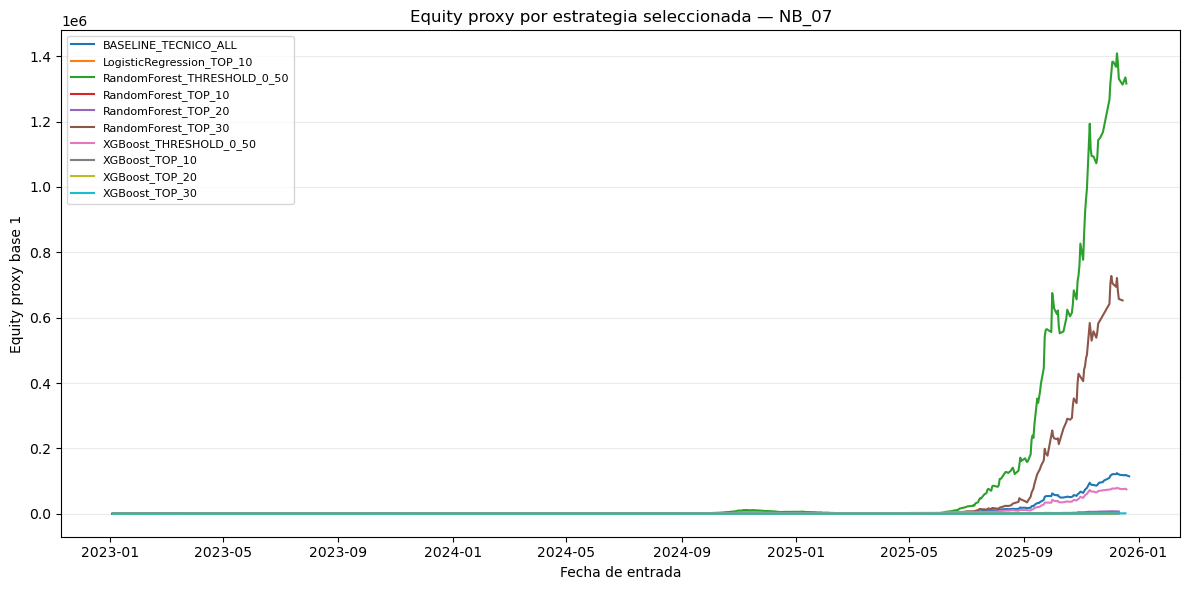

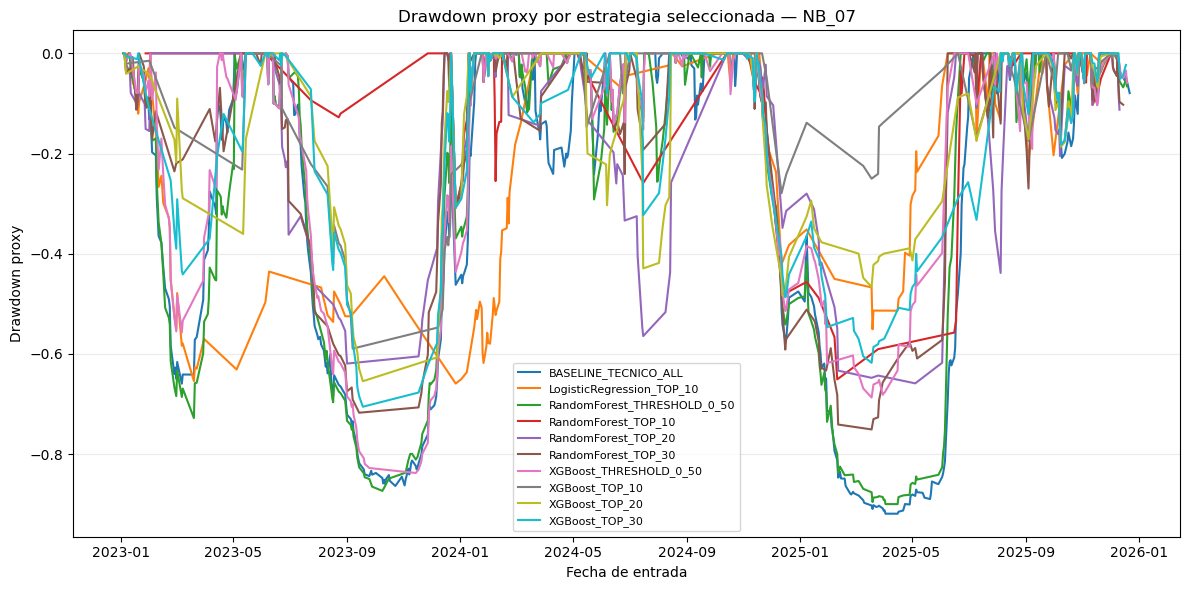

In [10]:
# ============================================================
# 10. Equity proxy y drawdown proxy
# ============================================================

# Se crea una equity proxy a partir del retorno medio diario de las señales seleccionadas.
# No es una cartera real con capital limitado; es una forma de visualizar el efecto de seleccionar señales por score.

all_daily = []
for strategy, sub in selected_signals_all.groupby('strategy'):
    if strategy not in key_strategies:
        continue
    dpr = daily_proxy_returns(sub)
    if dpr.empty:
        continue
    dpr['strategy'] = strategy
    all_daily.append(dpr)

daily_proxy_all = pd.concat(all_daily, ignore_index=True) if all_daily else pd.DataFrame()
daily_proxy_all.to_csv(OUT_DIR / 'daily_proxy_returns_nb07.csv', index=False)

plt.figure(figsize=(12, 6))
for strategy, sub in daily_proxy_all.groupby('strategy'):
    plt.plot(sub['entry_date'], sub['equity_proxy'], label=strategy)
plt.title('Equity proxy por estrategia seleccionada — NB_07')
plt.xlabel('Fecha de entrada')
plt.ylabel('Equity proxy base 1')
plt.legend(fontsize=8)
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(EQUITY_DIR / 'equity_proxy_key_strategies_nb07.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close()

plt.figure(figsize=(12, 6))
for strategy, sub in daily_proxy_all.groupby('strategy'):
    plt.plot(sub['entry_date'], sub['drawdown_proxy'], label=strategy)
plt.title('Drawdown proxy por estrategia seleccionada — NB_07')
plt.xlabel('Fecha de entrada')
plt.ylabel('Drawdown proxy')
plt.legend(fontsize=8)
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(EQUITY_DIR / 'drawdown_proxy_key_strategies_nb07.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close()

strategy,BASELINE_TECNICO_ALL,LogisticRegression_TOP_10,RandomForest_THRESHOLD_0_50,RandomForest_TOP_10,RandomForest_TOP_20,RandomForest_TOP_30,XGBoost_THRESHOLD_0_50,XGBoost_TOP_10,XGBoost_TOP_20,XGBoost_TOP_30
test_year,,,,,,,,,,
2023,0.4509,0.3846,0.4764,0.6923,0.5879,0.5714,0.4777,0.4725,0.4670,0.4762
2024,0.5808,0.6364,0.6093,0.6503,0.6329,0.6247,0.6118,0.6923,0.6014,0.6084
2025,0.4913,0.6129,0.5310,0.6344,0.5622,0.5719,0.5051,0.6129,0.5459,0.5540


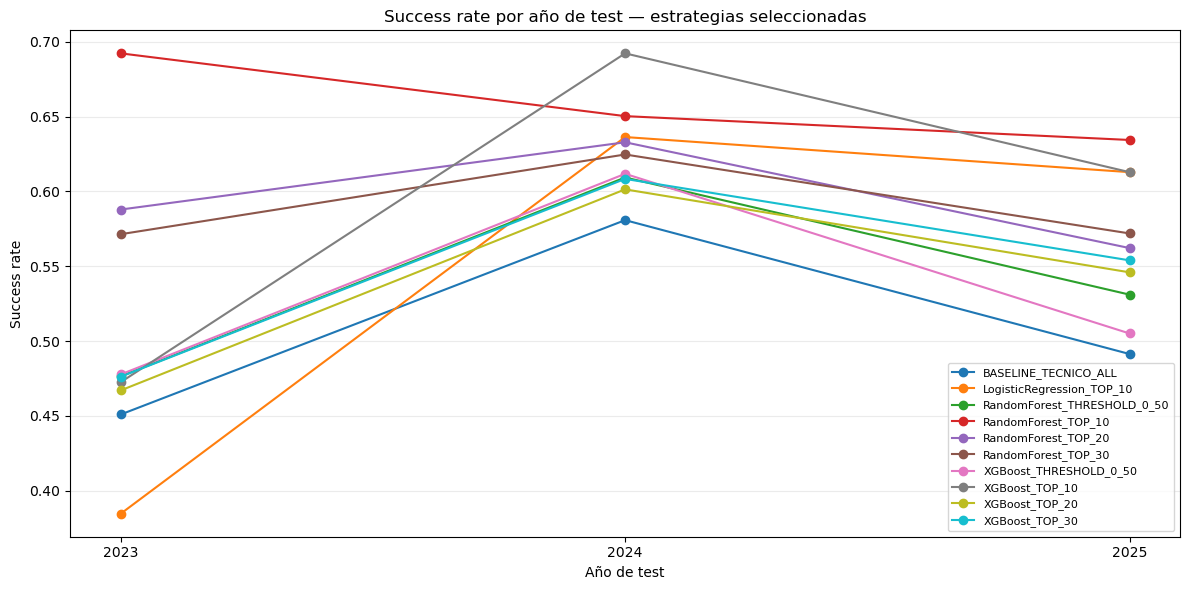

strategy,BASELINE_TECNICO_ALL,LogisticRegression_TOP_10,RandomForest_THRESHOLD_0_50,RandomForest_TOP_10,RandomForest_TOP_20,RandomForest_TOP_30,XGBoost_THRESHOLD_0_50,XGBoost_TOP_10,XGBoost_TOP_20,XGBoost_TOP_30
test_year,,,,,,,,,,
2023,0.0084,-0.0118,0.0123,0.0571,0.0405,0.0315,0.0127,0.0167,0.0150,0.0153
2024,0.0294,0.0396,0.0375,0.0446,0.0456,0.0429,0.0379,0.0565,0.0431,0.0369
2025,0.0268,0.1209,0.0424,0.1101,0.0786,0.0759,0.0323,0.0728,0.0440,0.0411


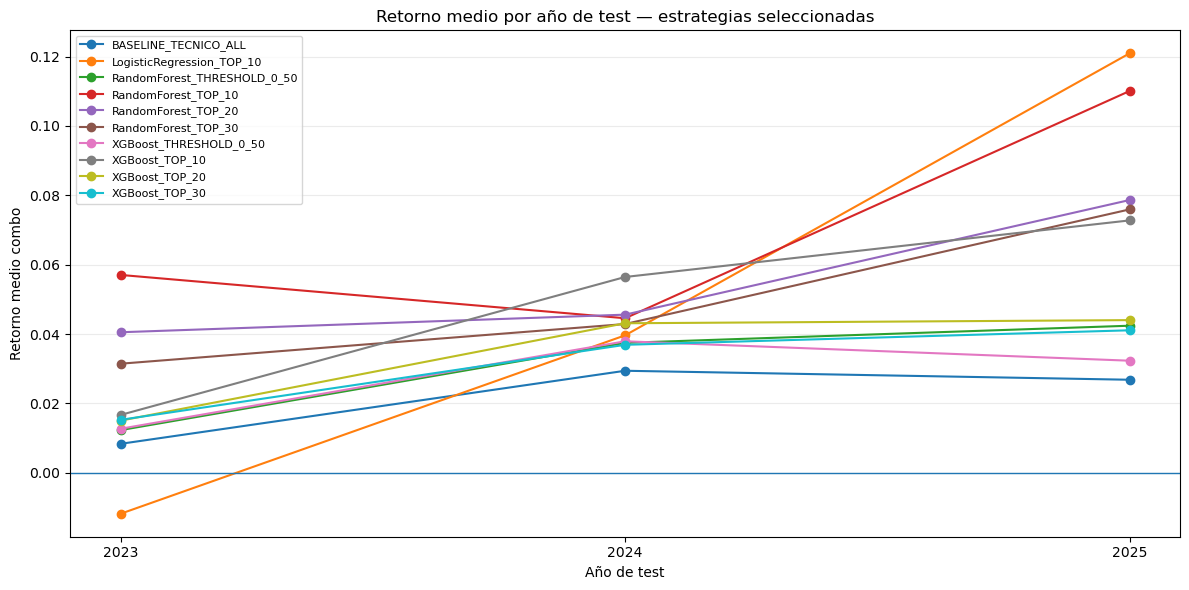

In [11]:
# ============================================================
# 11. Comparación por año de test
# ============================================================

plot_year = yearly_metrics[yearly_metrics['strategy'].isin(key_strategies)].copy()

# Success rate por año y estrategia principal
pivot_success = plot_year.pivot_table(index='test_year', columns='strategy', values='success_rate', aggfunc='mean')
display(pivot_success)
pivot_success.to_csv(TABLE_DIR / 'yearly_success_rate_pivot_nb07.csv')

plt.figure(figsize=(12, 6))
for col in pivot_success.columns:
    plt.plot(pivot_success.index, pivot_success[col], marker='o', label=col)
plt.title('Success rate por año de test — estrategias seleccionadas')
plt.xlabel('Año de test')
plt.ylabel('Success rate')
plt.xticks(pivot_success.index)
plt.legend(fontsize=8)
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(YEAR_DIR / 'yearly_success_rate_key_strategies_nb07.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close()

pivot_ret = plot_year.pivot_table(index='test_year', columns='strategy', values='mean_return', aggfunc='mean')
display(pivot_ret)
pivot_ret.to_csv(TABLE_DIR / 'yearly_mean_return_pivot_nb07.csv')

plt.figure(figsize=(12, 6))
for col in pivot_ret.columns:
    plt.plot(pivot_ret.index, pivot_ret[col], marker='o', label=col)
plt.axhline(0, linewidth=1)
plt.title('Retorno medio por año de test — estrategias seleccionadas')
plt.xlabel('Año de test')
plt.ylabel('Retorno medio combo')
plt.xticks(pivot_ret.index)
plt.legend(fontsize=8)
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(YEAR_DIR / 'yearly_mean_return_key_strategies_nb07.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close()